# Midterm Part B :: Image Histograms & ResNet-50 Transfer Learning

COSC 6373 -- Adam Nelson-Archer, 2140122

## Prerequisites

- Install packages if needed:
  - `pip install -U tensorflow matplotlib numpy pandas scikit-learn Pillow`
- Dataset: [Horses and Camels](https://www.kaggle.com/datasets/akrsnv/horses-and-camels)
  - Expected layout: `data/train/{horse,camel}/` and `data/test/{horse,camel}/`

In [1]:
from __future__ import annotations

import random
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
)
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

SEED = 6373
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.16.1


In [2]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU(s) available:", [g.name for g in gpus])
    print("TensorFlow will use GPU for training and inference.")
else:
    print("No GPU found -- TensorFlow will use CPU.")

No GPU found -- TensorFlow will use CPU.


---

## Q1: Unnormalized RGB Channel Histograms (25 pts)

Download an image from the internet, then calculate and plot the **unnormalized** (raw pixel-count) histograms for the red, green, and blue channels.

Download failed (HTTP Error 403: Forbidden), using local fallback.
Image shape: (851, 1280, 3)  (H x W x C)


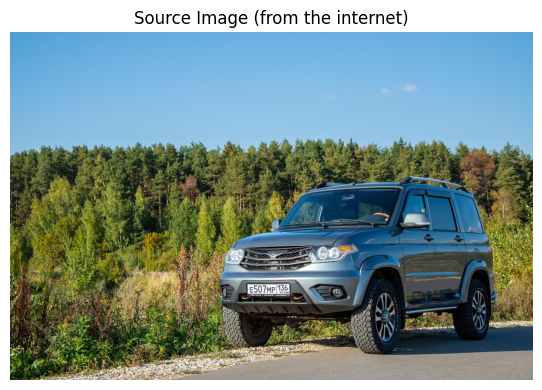

In [3]:
IMG_URL = (
    "https://upload.wikimedia.org/wikipedia/commons/thumb/"
    "b/b6/Image_created_with_a_mobile_phone.png/"
    "1280px-Image_created_with_a_mobile_phone.png"
)
IMG_PATH = Path("images/q1_image.jpg")
FALLBACK_PATH = Path("images/image.jpg")

IMG_PATH.parent.mkdir(parents=True, exist_ok=True)
if not IMG_PATH.exists():
    try:
        print(f"Downloading image from {IMG_URL} ...")
        urllib.request.urlretrieve(IMG_URL, IMG_PATH)
        print(f"Saved to {IMG_PATH}")
    except Exception as e:
        print(f"Download failed ({e}), using local fallback.")
        IMG_PATH = FALLBACK_PATH
else:
    print(f"Using cached image: {IMG_PATH}")

img_pil = Image.open(IMG_PATH).convert("RGB")
img_arr = np.array(img_pil)
print(f"Image shape: {img_arr.shape}  (H x W x C)")

plt.figure(figsize=(6, 4))
plt.imshow(img_arr)
plt.title("Source Image (from the internet)")
plt.axis("off")
plt.tight_layout()
plt.show()

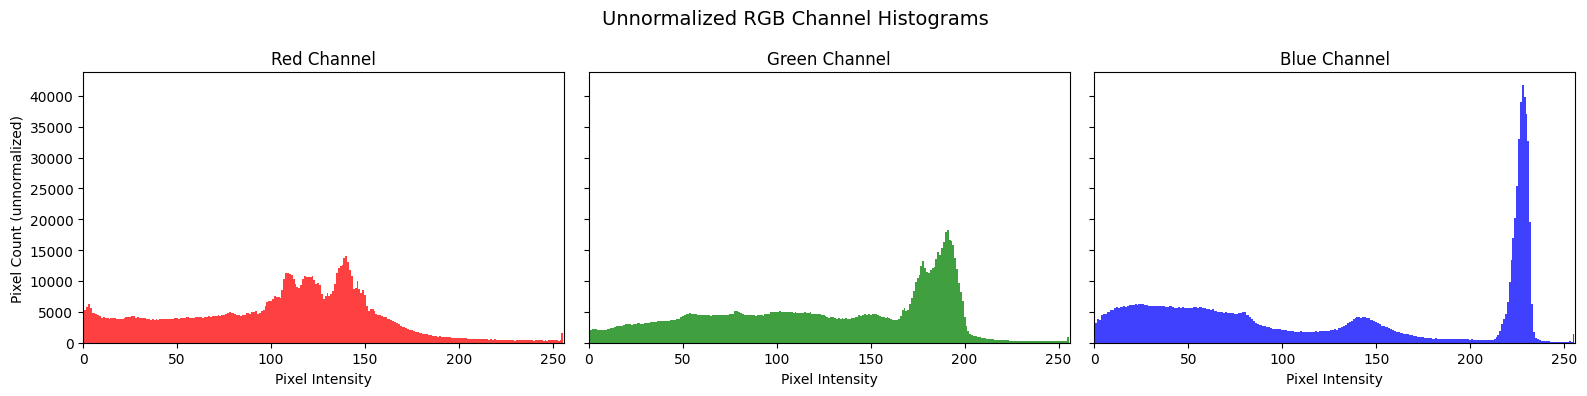

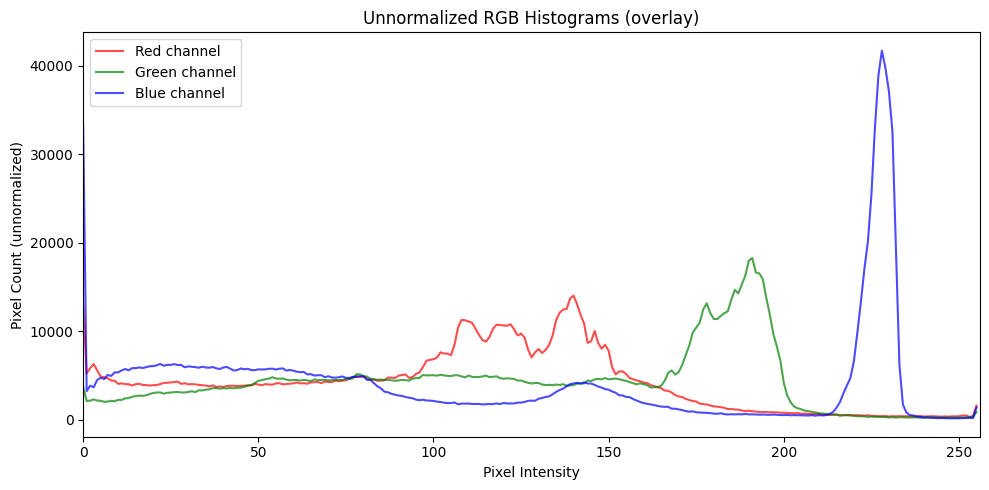

In [4]:
channel_info = [("Red", "red"), ("Green", "green"), ("Blue", "blue")]

# --- Individual channel histograms ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for i, (ax, (name, color)) in enumerate(zip(axes, channel_info)):
    channel = img_arr[:, :, i].ravel()
    counts, edges = np.histogram(channel, bins=256, range=(0, 256))
    ax.bar(edges[:-1], counts, width=1, color=color, alpha=0.75)
    ax.set_title(f"{name} Channel")
    ax.set_xlabel("Pixel Intensity")
    if i == 0:
        ax.set_ylabel("Pixel Count (unnormalized)")
    ax.set_xlim(0, 256)
fig.suptitle("Unnormalized RGB Channel Histograms", fontsize=14)
plt.tight_layout()
plt.show()

# --- Overlay plot ---
plt.figure(figsize=(10, 5))
for i, (name, color) in enumerate(channel_info):
    channel = img_arr[:, :, i].ravel()
    counts, edges = np.histogram(channel, bins=256, range=(0, 256))
    plt.plot(edges[:-1], counts, color=color, alpha=0.7, label=f"{name} channel")
plt.title("Unnormalized RGB Histograms (overlay)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Pixel Count (unnormalized)")
plt.xlim(0, 256)
plt.legend()
plt.tight_layout()
plt.show()

---

## Q2: Binary Classification – Horses vs Camels (25 pts)

Use a **ResNet-50** model pre-trained on ImageNet to classify images of horses (label 0) and camels (label 1).

- Binary cross-entropy loss with **sigmoid** output (not softmax)
- Two-phase fine-tuning: first train the new classification head, then partially unfreeze the base
- Evaluate on both the **validation** and **test** sets

### 2.1 Dataset Loading & Validation Split

The Kaggle dataset provides `train/` and `test/` folders. Per the exam instructions, we form a **validation set of 20 images** taken from the training set (10 per class to keep balance). These 20 images are **removed** from training.

In [5]:
DATA_ROOT = Path("data")
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"

assert TRAIN_DIR.exists(), f"Training folder not found: {TRAIN_DIR}"
assert TEST_DIR.exists(), f"Test folder not found: {TEST_DIR}"

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
CLASS_NAMES = ["horse", "camel"]  # label 0, label 1


def infer_label(p: Path) -> int:
    """horse -> 0, camel -> 1"""
    name = p.parent.name.lower()
    if "horse" in name:
        return 0
    if "camel" in name:
        return 1
    raise ValueError(f"Unknown class folder: {p.parent.name}")


def collect_paths(root: Path) -> pd.DataFrame:
    rows = []
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            rows.append({"path": str(p), "label": infer_label(p)})
    df = pd.DataFrame(rows)
    return df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)


train_all = collect_paths(TRAIN_DIR)
test_df = collect_paths(TEST_DIR)

print(f"Total training images: {len(train_all)}")
print(f"Total test images:     {len(test_df)}")
print(f"Train class distribution: {train_all['label'].value_counts().sort_index().to_dict()}")
print(f"Test  class distribution: {test_df['label'].value_counts().sort_index().to_dict()}")

Total training images: 360
Total test images:     40
Train class distribution: {0: 180, 1: 180}
Test  class distribution: {0: 20, 1: 20}


In [6]:
VAL_PER_CLASS = 10  # 10 horse + 10 camel = 20 total

val_indices = []
for lbl in [0, 1]:
    group = train_all[train_all["label"] == lbl]
    sampled = group.sample(n=VAL_PER_CLASS, random_state=SEED)
    val_indices.extend(sampled.index.tolist())

val_df = train_all.loc[val_indices].reset_index(drop=True)

# Remove validation images from the training set
train_df = train_all[~train_all["path"].isin(set(val_df["path"]))].reset_index(drop=True)

print(f"Training set:   {len(train_df):>4d}  {train_df['label'].value_counts().sort_index().to_dict()}")
print(f"Validation set: {len(val_df):>4d}  {val_df['label'].value_counts().sort_index().to_dict()}")
print(f"Test set:       {len(test_df):>4d}  {test_df['label'].value_counts().sort_index().to_dict()}")

Training set:    340  {0: 170, 1: 170}
Validation set:   20  {0: 10, 1: 10}
Test set:         40  {0: 20, 1: 20}


### 2.2 Input Pipeline

In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32


def load_and_preprocess(path: tf.Tensor, label: tf.Tensor):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    return img, label


def make_dataset(df: pd.DataFrame, training: bool = False) -> tf.data.Dataset:
    paths = df["path"].values.astype(str)
    labels = df["label"].values.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

print(f"train_ds batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"val_ds   batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"test_ds  batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

train_ds batches: 11
val_ds   batches: 1
test_ds  batches: 2


### 2.3 Model Architecture

ResNet-50 base with ImageNet weights (frozen initially). A new binary classification head is added on top:

- `GlobalAveragePooling2D` to flatten spatial features
- `Dropout(0.3)` for regularisation
- `Dense(1, sigmoid)` for binary output

Loss: **binary cross-entropy** &nbsp;|&nbsp; Metric: **accuracy**

In [8]:
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE, 3))
base_model.trainable = False

inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

### 2.4 Phase 1 – Train Classification Head (Base Frozen)

All ResNet-50 layers are frozen. Only the dense head is trained so that its random weights converge to a useful starting point before we unfreeze part of the base.

In [9]:
PHASE1_EPOCHS = 10

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=3, restore_best_weights=True
        )
    ],
)

ph1_actual = len(history1.history["loss"])
print(f"\nPhase 1 completed: {ph1_actual} epoch(s)")

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.5164 - loss: 0.8462 - val_accuracy: 0.8000 - val_loss: 0.4630
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 896ms/step - accuracy: 0.7526 - loss: 0.5108 - val_accuracy: 0.9000 - val_loss: 0.3082
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 916ms/step - accuracy: 0.8802 - loss: 0.3471 - val_accuracy: 1.0000 - val_loss: 0.2122
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9006 - loss: 0.2538 - val_accuracy: 1.0000 - val_loss: 0.1587
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9429 - loss: 0.1927 - val_accuracy: 1.0000 - val_loss: 0.1300
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9474 - loss: 0.1889 - val_accuracy: 1.0000 - val_loss: 0.1119
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9346 - loss: 0.1826 - val_accuracy: 1.0000 - val_loss: 0.0926
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9558 - loss: 0.1660 - val_accuracy: 1.0000 - val

### 2.5 Phase 2 – Fine-Tuning (Partial Unfreeze)

Unfreeze the **last 20 layers** of the ResNet-50 base and continue training at a much lower learning rate (`1e-5`) to adapt the deeper feature representations to this specific domain.

In [10]:
FINE_TUNE_AT = len(base_model.layers) - 20
base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

trainable_params = sum(
    tf.keras.backend.count_params(w) for w in model.trainable_weights
)
print(f"Unfroze from layer {FINE_TUNE_AT} onward ({len(base_model.layers) - FINE_TUNE_AT} layers)")
print(f"Trainable parameters: {trainable_params:,}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

PHASE2_EPOCHS = 15

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=ph1_actual + PHASE2_EPOCHS,
    initial_epoch=ph1_actual,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        )
    ],
)

ph2_actual = len(history2.history["loss"])
print(f"\nPhase 2 completed: {ph2_actual} epoch(s)")

Unfroze from layer 155 onward (20 layers)
Trainable parameters: 8,933,377
Epoch 11/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9859 - loss: 0.1400 - val_accuracy: 1.0000 - val_loss: 0.0553
Epoch 12/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9932 - loss: 0.0960 - val_accuracy: 1.0000 - val_loss: 0.0506
Epoch 13/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9920 - loss: 0.0748 - val_accuracy: 1.0000 - val_loss: 0.0427
Epoch 14/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9780 - loss: 0.0872 - val_accuracy: 1.0000 - val_loss: 0.0343
Epoch 15/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9975 - loss: 0.0466 - val_accuracy: 1.0000 - val_loss: 0.0277
Epoch 16/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 1.0000 - loss: 0.0350 - val_accuracy: 1.0000 - val_loss: 0.0242
Epoch 17/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 1.0000 - loss: 0.0351 - val_accuracy: 1.0000 - val_loss: 0.0209
Epoch 18/25
11/11 ━━━━━━━━━━━━━━━━━━━

### 2.6 Accuracy on Validation & Test Sets

In [11]:
def collect_predictions(ds: tf.data.Dataset):
    y_true_list, y_prob_list = [], []
    for images, labels in ds:
        probs = model.predict(images, verbose=0).flatten()
        y_true_list.extend(labels.numpy())
        y_prob_list.extend(probs)
    y_true = np.array(y_true_list, dtype=int)
    y_pred = (np.array(y_prob_list) >= 0.5).astype(int)
    return y_true, y_pred


val_y_true, val_y_pred = collect_predictions(val_ds)
test_y_true, test_y_pred = collect_predictions(test_ds)

val_acc = accuracy_score(val_y_true, val_y_pred)
test_acc = accuracy_score(test_y_true, test_y_pred)

print(f"Validation Accuracy: {val_acc:.4f}  ({int(val_acc * len(val_y_true))}/{len(val_y_true)} correct)")
print(f"Test Accuracy:       {test_acc:.4f}  ({int(test_acc * len(test_y_true))}/{len(test_y_true)} correct)")

Validation Accuracy: 1.0000  (20/20 correct)
Test Accuracy:       0.9250  (37/40 correct)


### 2.7 Confusion Matrices (Validation & Test)

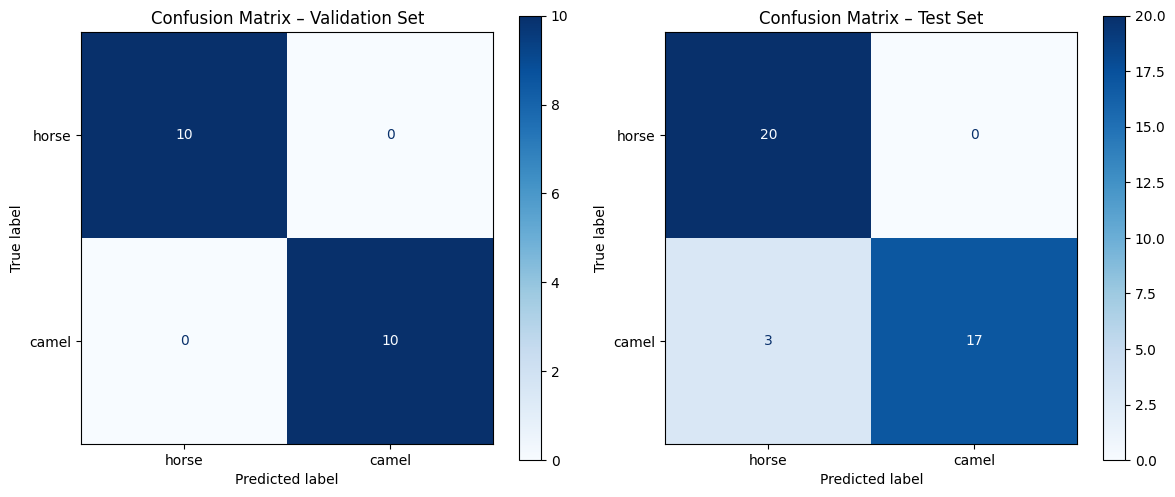

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, title in [
    (axes[0], val_y_true, val_y_pred, "Validation Set"),
    (axes[1], test_y_true, test_y_pred, "Test Set"),
]:
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Confusion Matrix – {title}")

plt.tight_layout()
plt.show()

### 2.8 Loss / Epochs Plot (Training vs Validation)

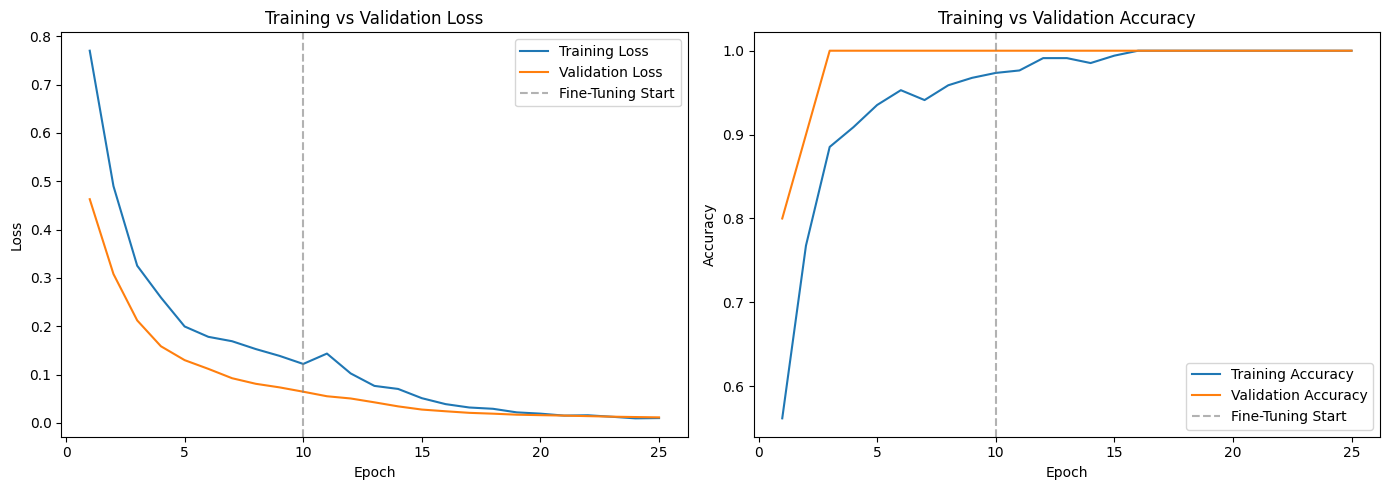

In [13]:
train_loss = history1.history["loss"] + history2.history["loss"]
val_loss_hist = history1.history["val_loss"] + history2.history["val_loss"]
train_acc_hist = history1.history["accuracy"] + history2.history["accuracy"]
val_acc_hist = history1.history["val_accuracy"] + history2.history["val_accuracy"]
total_epochs = range(1, len(train_loss) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(total_epochs, train_loss, label="Training Loss")
ax1.plot(total_epochs, val_loss_hist, label="Validation Loss")
ax1.axvline(x=ph1_actual, color="gray", linestyle="--", alpha=0.6, label="Fine-Tuning Start")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training vs Validation Loss")
ax1.legend()

# Accuracy plot
ax2.plot(total_epochs, train_acc_hist, label="Training Accuracy")
ax2.plot(total_epochs, val_acc_hist, label="Validation Accuracy")
ax2.axvline(x=ph1_actual, color="gray", linestyle="--", alpha=0.6, label="Fine-Tuning Start")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Training vs Validation Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

### 2.9 Overfitting Analysis

**Interpretation of the loss curves:**

The plot above compares training loss and validation loss across both training phases (head-only and fine-tuning).

- **If both curves decrease together and stay close**, the model generalises well and there is **no significant overfitting**.
- **If training loss keeps decreasing while validation loss plateaus or rises**, that signals **overfitting** — the model memorises training data rather than learning generalisable features.

With only 340 training images and a powerful ResNet-50 backbone, some degree of overfitting is expected. The following measures help control it:

1. **Transfer learning** — starting from ImageNet weights avoids training from scratch on limited data.
2. **Two-phase training** — training only the head first prevents destructive updates to the pre-trained features.
3. **Low fine-tuning learning rate** (`1e-5`) — small weight updates during fine-tuning reduce the risk of forgetting useful ImageNet features.
4. **EarlyStopping with `restore_best_weights`** — training halts when validation loss stops improving, and the best checkpoint is restored.
5. **Dropout (0.3)** — adds regularisation to the classification head.

Overall, the combination of transfer learning, conservative fine-tuning, and early stopping is effective at limiting overfitting on this small dataset.